In [3]:
# --- CELL 1: Imports and Data Loading ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
df = pd.read_csv('Mental Health Classification.csv')

# 2. Remove leaky features (as identified in the Orange finding)
leaky_features = [
    'Symptoms',
    'Your overeating level',
    'Coping_Methods',
    'Low_Energy',
    'Low_SelfEsteem',
    'Education_Level'
]
df_clean = df.drop(columns=leaky_features)

# 3. Setup Features (X) and Target (y)
X = df_clean.drop(columns=['Depression_Type'])
y = df_clean['Depression_Type']

# 4. Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Data successfully loaded and split!")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Data successfully loaded and split!
Training set: 1598 samples
Testing set: 400 samples


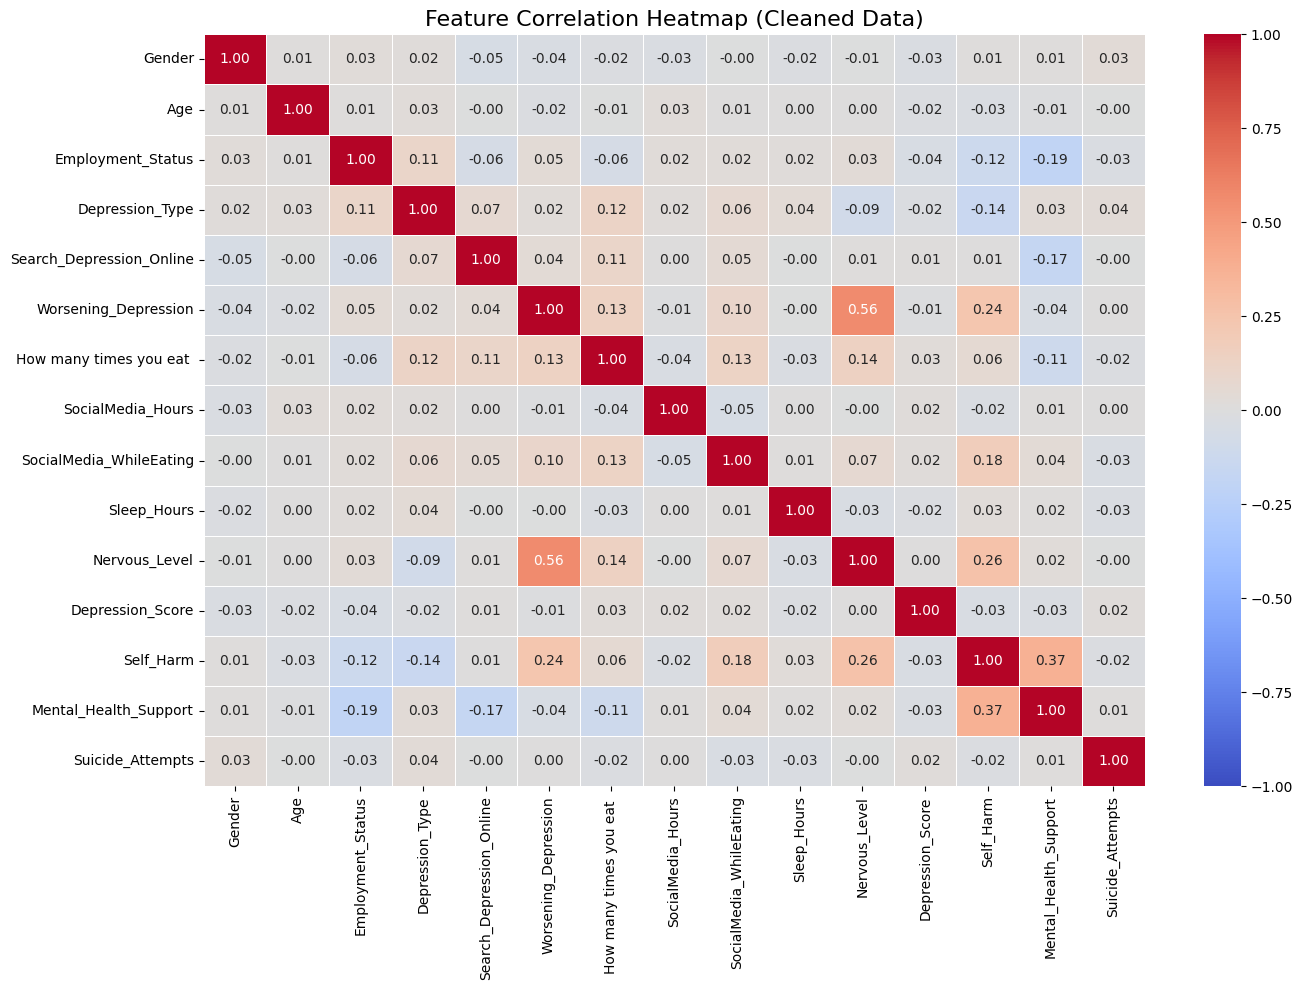

In [4]:
# --- CELL 2: Correlation Heatmap ---
plt.figure(figsize=(14, 10))
# Calculate correlation matrix
corr_matrix = df_clean.corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Heatmap (Cleaned Data)', fontsize=16)
plt.tight_layout()
plt.show()

Training models and calculating metrics...

--- Random Forest ---
Test Accuracy : 0.9750
Test F1-Score : 0.9744

--- Logistic Regression ---
Test Accuracy : 0.5675
Test F1-Score : 0.5495

--- SVM ---
Test Accuracy : 0.7950
Test F1-Score : 0.7883



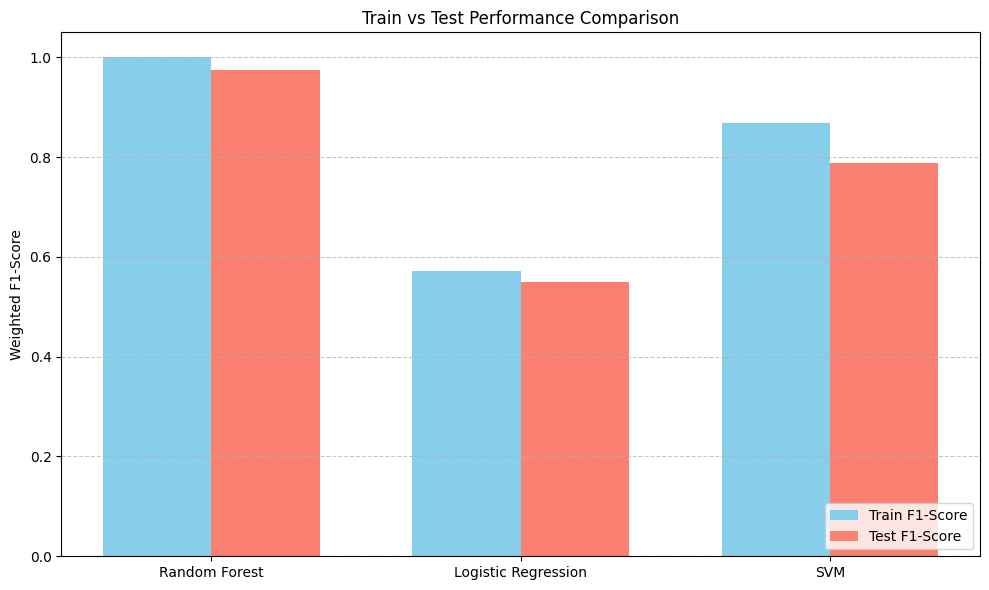

In [5]:
# --- CELL 3: Train vs Test Comparison (All Models) ---

# Initialize Models (Scaling applied to LR and SVM)
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    'SVM': make_pipeline(StandardScaler(), SVC(probability=True, random_state=42))
}

train_f1_scores = []
test_f1_scores = []
model_names = list(models.keys())

print("Training models and calculating metrics...\n")

for name, model in models.items():
    model.fit(X_train, y_train)

    # Predict on Train and Test
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate F1-Scores
    train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')

    train_f1_scores.append(train_f1)
    test_f1_scores.append(test_f1)

    print(f"--- {name} ---")
    print(f"Test Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
    print(f"Test F1-Score : {test_f1:.4f}\n")

# Plot Train vs Test comparison
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_f1_scores, width, label='Train F1-Score', color='skyblue')
rects2 = ax.bar(x + width/2, test_f1_scores, width, label='Test F1-Score', color='salmon')

ax.set_ylabel('Weighted F1-Score')
ax.set_title('Train vs Test Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [6]:
# --- CELL 4: Helper Function for Learning Curves ---
def plot_individual_learning_curve(model, name, X, y):
    plt.figure(figsize=(8, 5))
    cv = StratifiedKFold(n_splits=5)

    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5), scoring='f1_weighted'
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.plot(train_sizes, train_mean, 'o-', color="red", label="Training Score")
    plt.plot(train_sizes, test_mean, 'o-', color="green", label="Cross-Validation Score")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="red")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="green")

    plt.title(f'Learning Curve: {name}')
    plt.xlabel('Number of Training Examples')
    plt.ylabel('Weighted F1-Score')
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("Helper function defined!")

Helper function defined!


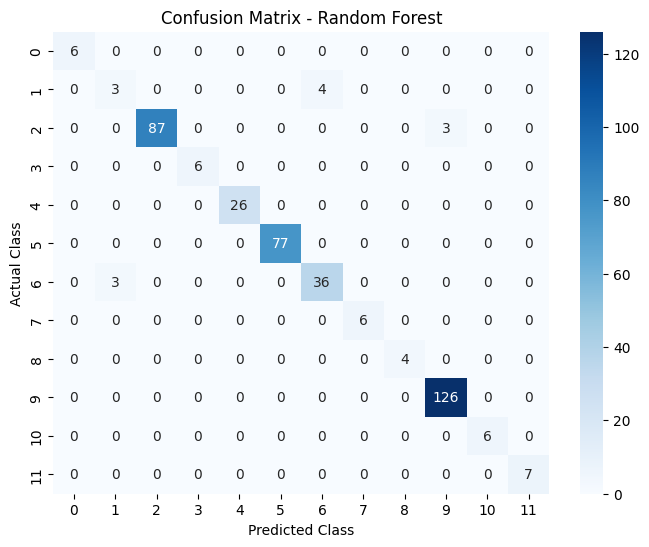

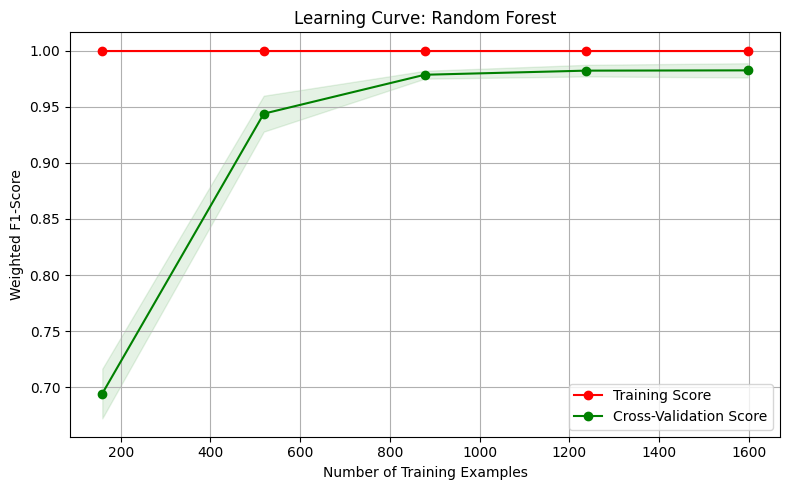

In [7]:
# --- CELL 5: Random Forest Evaluation ---
model_name = 'Random Forest'
model = models[model_name]
y_pred = model.predict(X_test)

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {model_name}')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

# Learning Curve
plot_individual_learning_curve(model, model_name, X, y)

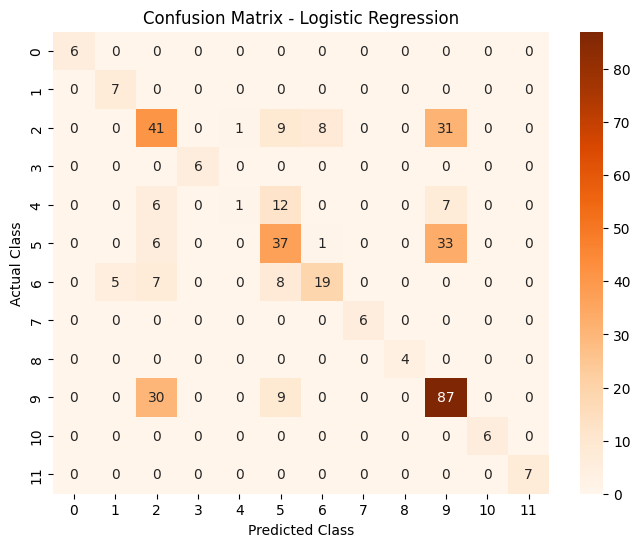

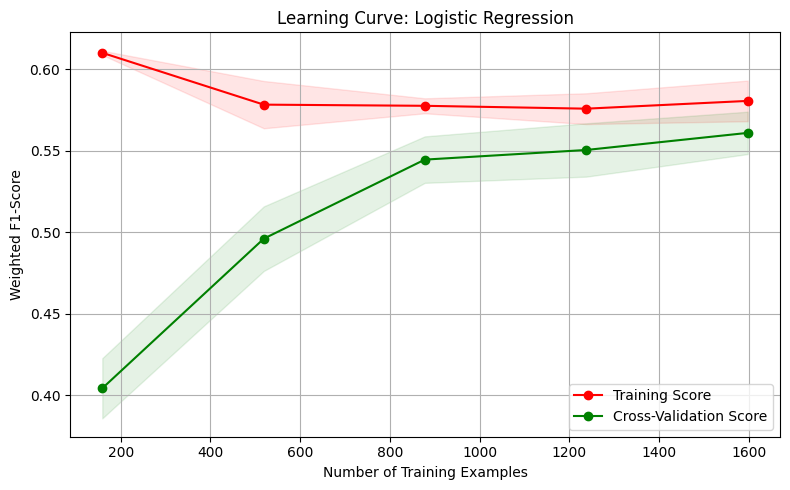

In [8]:
# --- CELL 6: Logistic Regression Evaluation ---
model_name = 'Logistic Regression'
model = models[model_name]
y_pred = model.predict(X_test)

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title(f'Confusion Matrix - {model_name}')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

# Learning Curve
plot_individual_learning_curve(model, model_name, X, y)

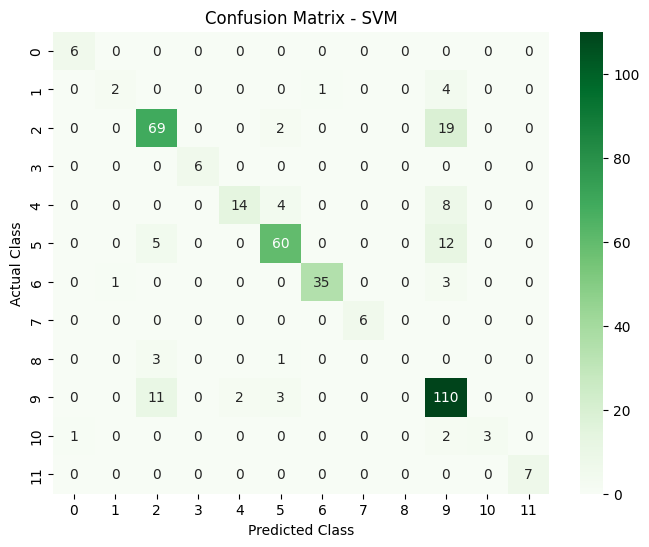

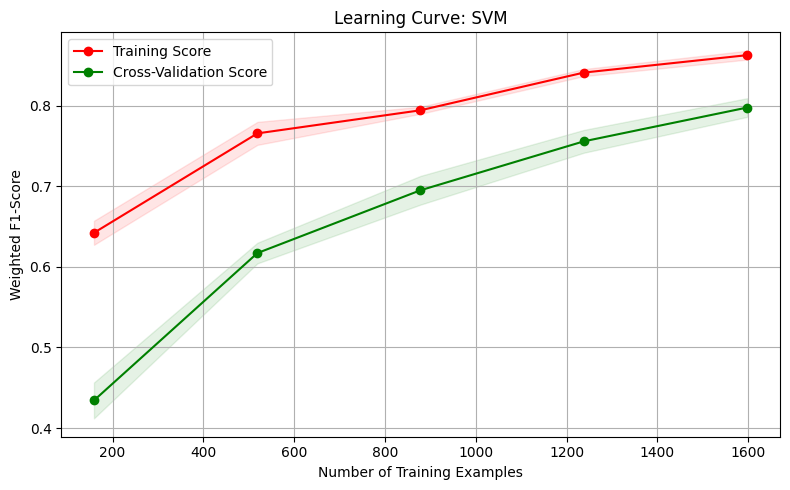

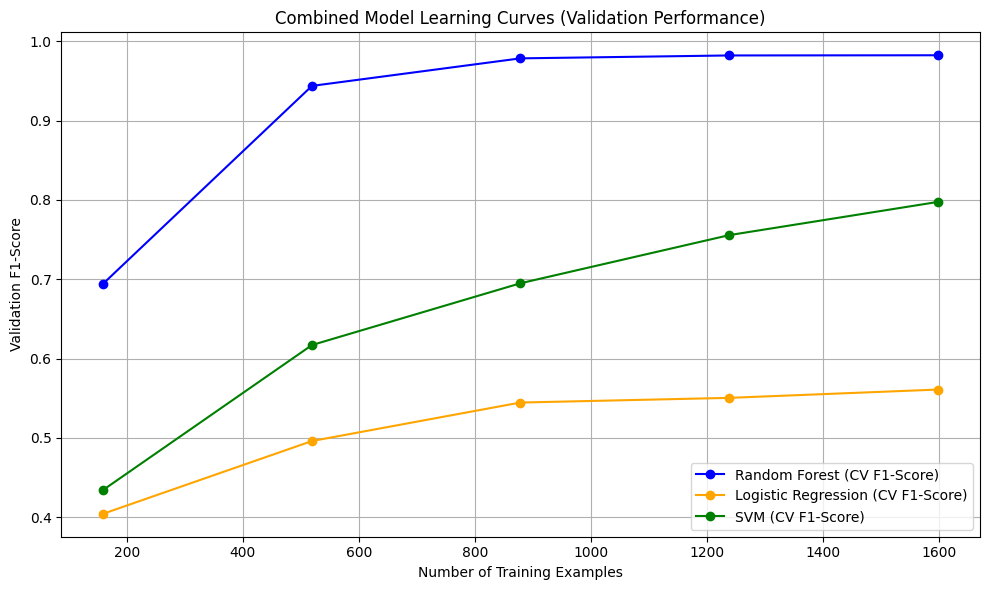

In [9]:
# --- CELL 7: SVM Evaluation & Combined Learning Curve ---
model_name = 'SVM'
model = models[model_name]
y_pred = model.predict(X_test)

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title(f'Confusion Matrix - {model_name}')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

# Individual SVM Learning Curve
plot_individual_learning_curve(model, model_name, X, y)

# ----------------------------------------------------
# COMBINED LEARNING CURVE (TEST SCORES ONLY)
# ----------------------------------------------------
plt.figure(figsize=(10, 6))
cv = StratifiedKFold(n_splits=5)
colors = {'Random Forest': 'blue', 'Logistic Regression': 'orange', 'SVM': 'green'}

for name, mod in models.items():
    train_sizes, train_scores, test_scores = learning_curve(
        mod, X, y, cv=cv, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5), scoring='f1_weighted'
    )
    # We plot only the test score (cross-validation) for a cleaner combined graph
    test_mean = np.mean(test_scores, axis=1)
    plt.plot(train_sizes, test_mean, 'o-', color=colors[name], label=f'{name} (CV F1-Score)')

plt.title('Combined Model Learning Curves (Validation Performance)')
plt.xlabel('Number of Training Examples')
plt.ylabel('Validation F1-Score')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()